# Pickleball Clip Splicing MVP v2

This notebook analyzes pickleball videos to:
1. **Detect the ball** using multi-strategy fusion (YOLO + color + optical flow)
2. **Identify hits** based on speed peaks and direction changes
3. **Segment volleys** into phases: preparation, approach, contact, follow-through
4. **Export clips** for each volley and phase

## Improvements over v1:
- Detection rate: 21% -> 84% (4x improvement)
- Multi-strategy ball detection (YOLO + color + optical flow)
- Better hit detection using combined scoring
- Refined phase segmentation based on ball motion

In [1]:
import cv2
import numpy as np
from ultralytics import YOLO
from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import interp1d
import os
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

VIDEO_PATH = "test_15sec.mp4"  # Input video
OUTPUT_DIR = "output_clips_v2"  # Output directory

# Detection parameters
YOLO_CONF = 0.1  # Lower = more detections (may include false positives)
SPORTS_BALL_CLASS = 32  # COCO class ID

# Color detection (for yellow/green pickleballs)
COLOR_SEARCH_RADIUS = 250  # Pixels to search around previous position

# Motion validation
MAX_BALL_SPEED = 2500  # Max physically possible speed (px/s)

# Hit detection
MIN_FRAMES_BETWEEN_HITS = 10  # ~0.33s at 30fps
HIT_SCORE_THRESHOLD = 0.2

# Smoothing
SMOOTH_WINDOW = 15  # Frames for Savitzky-Golay filter

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}/")

Output will be saved to: output_clips_v2/


In [3]:
# Load YOLO model
model = YOLO("yolo26n.pt")
print("YOLO model loaded")

YOLO model loaded


In [4]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def load_video(path):
    """Load video frames and metadata."""
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    
    print(f"Loaded {len(frames)} frames at {fps:.2f} FPS ({width}x{height})")
    return frames, fps, (width, height)


def save_clip(frames, fps, path, size):
    """Save frames as MP4 video."""
    out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), fps, size)
    for f in frames:
        out.write(f)
    out.release()

In [6]:
# ============================================================
# STRATEGY 1: YOLO DETECTION
# ============================================================

def detect_yolo(frames, conf=YOLO_CONF):
    """Detect ball using YOLO in each frame."""
    positions = [None] * len(frames)
    confidences = [0.0] * len(frames)
    
    for i, frame in enumerate(frames):
        if i % 100 == 0:
            print(f"  YOLO: frame {i}/{len(frames)}")
        
        results = model(frame, conf=conf, verbose=False)
        
        for r in results:
            for box in r.boxes:
                if int(box.cls[0]) != SPORTS_BALL_CLASS:
                    continue
                c = float(box.conf[0])
                if c > confidences[i]:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    positions[i] = ((x1 + x2) / 2, (y1 + y2) / 2)
                    confidences[i] = c
    
    detected = sum(1 for p in positions if p is not None)
    print(f"  YOLO detected: {detected}/{len(frames)} ({100*detected/len(frames):.1f}%)")
    return positions, confidences

In [7]:
# ============================================================
# STRATEGY 2: COLOR-BASED DETECTION
# ============================================================

def detect_by_color(frame, hint_pos=None, search_radius=COLOR_SEARCH_RADIUS):
    """Detect yellow/green pickleball by color."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # Color ranges for pickleballs
    masks = [
        cv2.inRange(hsv, np.array([20, 80, 150]), np.array([40, 255, 255])),   # Yellow
        cv2.inRange(hsv, np.array([35, 80, 150]), np.array([75, 255, 255])),   # Lime green
        cv2.inRange(hsv, np.array([10, 100, 150]), np.array([25, 255, 255]))   # Orange-yellow
    ]
    
    mask = masks[0]
    for m in masks[1:]:
        mask = cv2.bitwise_or(mask, m)
    
    # Clean up mask
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Restrict search area if hint provided
    if hint_pos is not None:
        roi_mask = np.zeros_like(mask)
        cv2.circle(roi_mask, (int(hint_pos[0]), int(hint_pos[1])), search_radius, 255, -1)
        mask = cv2.bitwise_and(mask, roi_mask)
    
    # Find circular blobs
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    best, best_score = None, 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 30 or area > 3000:
            continue
        
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        
        circularity = 4 * np.pi * area / (perimeter ** 2)
        if circularity < 0.4:
            continue
        
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        
        cx, cy = M["m10"] / M["m00"], M["m01"] / M["m00"]
        
        # Score by circularity and size
        score = circularity * min(area, 500)
        if hint_pos is not None:
            dist = np.sqrt((cx - hint_pos[0])**2 + (cy - hint_pos[1])**2)
            score *= (1 + max(0, 1 - dist / search_radius))
        
        if score > best_score:
            best, best_score = (cx, cy), score
    
    return best


def detect_color_all(frames, yolo_positions):
    """Run color detection on all frames using YOLO as hints."""
    positions = []
    prev_pos = None
    
    for i, frame in enumerate(frames):
        hint = yolo_positions[i] if yolo_positions[i] else prev_pos
        pos = detect_by_color(frame, hint)
        positions.append(pos)
        
        if pos:
            prev_pos = pos
        elif yolo_positions[i]:
            prev_pos = yolo_positions[i]
    
    detected = sum(1 for p in positions if p is not None)
    print(f"  Color detected: {detected}/{len(frames)} ({100*detected/len(frames):.1f}%)")
    return positions

In [8]:
# ============================================================
# STRATEGY 3: OPTICAL FLOW TRACKING
# ============================================================

def track_optical_flow(frames, seed_positions):
    """Track ball using optical flow to fill gaps."""
    positions = list(seed_positions)
    
    lk_params = dict(
        winSize=(21, 21),
        maxLevel=3,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
    )
    
    # Forward pass
    prev_gray, prev_pt = None, None
    for i, frame in enumerate(frames):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        if positions[i]:
            prev_pt = np.array([[positions[i]]], dtype=np.float32)
        elif prev_gray is not None and prev_pt is not None:
            new_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev_gray, gray, prev_pt, None, **lk_params
            )
            if status[0][0] == 1:
                x, y = new_pts[0][0]
                if 0 < x < frame.shape[1] and 0 < y < frame.shape[0]:
                    positions[i] = (float(x), float(y))
                    prev_pt = new_pts
        prev_gray = gray
    
    # Backward pass
    prev_gray, prev_pt = None, None
    for i in range(len(frames) - 1, -1, -1):
        gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        
        if positions[i]:
            prev_pt = np.array([[positions[i]]], dtype=np.float32)
        elif prev_gray is not None and prev_pt is not None:
            new_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev_gray, gray, prev_pt, None, **lk_params
            )
            if status[0][0] == 1:
                x, y = new_pts[0][0]
                if 0 < x < frames[i].shape[1] and 0 < y < frames[i].shape[0]:
                    positions[i] = (float(x), float(y))
                    prev_pt = new_pts
        prev_gray = gray
    
    detected = sum(1 for p in positions if p is not None)
    print(f"  Optical flow: {detected}/{len(frames)} ({100*detected/len(frames):.1f}%)")
    return positions

In [9]:
# ============================================================
# DETECTION FUSION & VALIDATION
# ============================================================

def fuse_detections(yolo_pos, yolo_conf, color_pos, flow_pos):
    """Combine detections with confidence weighting."""
    fused = []
    
    for i in range(len(yolo_pos)):
        candidates = []
        
        # YOLO (weight by confidence)
        if yolo_pos[i]:
            candidates.append((yolo_pos[i], 0.5 + yolo_conf[i] * 0.5))
        
        # Color detection
        if color_pos[i]:
            weight = 0.6
            if yolo_pos[i]:
                dist = np.sqrt((color_pos[i][0] - yolo_pos[i][0])**2 + 
                              (color_pos[i][1] - yolo_pos[i][1])**2)
                if dist < 50:
                    weight = 0.85  # Boost if agrees with YOLO
            candidates.append((color_pos[i], weight))
        
        # Optical flow
        if flow_pos[i]:
            weight = 0.4
            for pos, _ in candidates:
                dist = np.sqrt((flow_pos[i][0] - pos[0])**2 + 
                              (flow_pos[i][1] - pos[1])**2)
                if dist < 40:
                    weight = 0.6
                    break
            candidates.append((flow_pos[i], weight))
        
        if candidates:
            total_w = sum(c[1] for c in candidates)
            x = sum(c[0][0] * c[1] for c in candidates) / total_w
            y = sum(c[0][1] * c[1] for c in candidates) / total_w
            fused.append((x, y))
        else:
            fused.append(None)
    
    detected = sum(1 for p in fused if p is not None)
    print(f"  Fused: {detected}/{len(fused)} ({100*detected/len(fused):.1f}%)")
    return fused


def validate_trajectory(positions, fps, max_speed=MAX_BALL_SPEED):
    """Remove physically impossible detections."""
    validated = list(positions)
    max_dist = max_speed / fps
    
    for i in range(1, len(validated) - 1):
        if not validated[i]:
            continue
        
        # Check distance to previous valid position
        for j in range(i - 1, max(0, i - 5) - 1, -1):
            if validated[j]:
                dist = np.sqrt((validated[i][0] - validated[j][0])**2 + 
                              (validated[i][1] - validated[j][1])**2)
                if dist > max_dist * (i - j) * 1.5:
                    validated[i] = None
                break
    
    detected = sum(1 for p in validated if p is not None)
    print(f"  Validated: {detected}/{len(validated)} ({100*detected/len(validated):.1f}%)")
    return validated

In [10]:
# ============================================================
# TRAJECTORY PROCESSING
# ============================================================

def interpolate_and_smooth(positions, window=SMOOTH_WINDOW):
    """Interpolate gaps and smooth trajectory."""
    n = len(positions)
    valid_idx = [i for i, p in enumerate(positions) if p]
    
    if len(valid_idx) < 2:
        return np.zeros((n, 2)), np.zeros(n, dtype=bool)
    
    vx = [positions[i][0] for i in valid_idx]
    vy = [positions[i][1] for i in valid_idx]
    
    fx = interp1d(valid_idx, vx, kind='linear', bounds_error=False, fill_value='extrapolate')
    fy = interp1d(valid_idx, vy, kind='linear', bounds_error=False, fill_value='extrapolate')
    
    interp = np.column_stack([fx(np.arange(n)), fy(np.arange(n))])
    reliability = np.array([p is not None for p in positions])
    
    # Smooth
    if len(interp) >= window:
        interp[:, 0] = savgol_filter(interp[:, 0], window, 3)
        interp[:, 1] = savgol_filter(interp[:, 1], window, 3)
    
    return interp, reliability


def compute_motion(positions, fps):
    """Compute velocity, speed, direction."""
    vel = np.diff(positions, axis=0) * fps
    speed = np.linalg.norm(vel, axis=1)
    dir_x = vel[:, 0]
    
    # Pad to match length
    speed = np.concatenate([[speed[0]], speed])
    dir_x = np.concatenate([[dir_x[0]], dir_x])
    
    return speed, dir_x

In [11]:
# ============================================================
# HIT DETECTION
# ============================================================

def detect_hits(speed, dir_x, fps, min_gap=MIN_FRAMES_BETWEEN_HITS):
    """
    Detect hits using combined scoring:
    - Speed peaks (ball moving fast)
    - Direction changes (ball reverses)
    """
    n = len(speed)
    
    # Normalize speed
    speed_norm = (speed - np.mean(speed)) / (np.std(speed) + 1e-6)
    
    # Detect direction reversals
    dir_change = np.zeros(n)
    for i in range(3, n - 3):
        before = np.mean(dir_x[max(0, i-3):i])
        after = np.mean(dir_x[i+1:min(n, i+4)])
        if before * after < 0:  # Sign change
            dir_change[i] = abs(before - after)
    
    # Combined hit score
    hit_score = speed_norm * 0.5 + dir_change * 0.5
    
    # Find peaks
    speed_thresh = np.percentile(speed, 65)
    peaks, _ = find_peaks(
        hit_score,
        height=HIT_SCORE_THRESHOLD,
        distance=min_gap,
        prominence=0.15
    )
    
    # Filter by speed
    hits = [p for p in peaks if speed[p] > speed_thresh * 0.6]
    
    # Fallback to speed-only detection
    if len(hits) < 2:
        print("  Falling back to speed-only detection")
        peaks, _ = find_peaks(speed, height=speed_thresh, distance=min_gap)
        hits = list(peaks)
    
    return sorted(hits), hit_score, dir_change

In [12]:
# ============================================================
# VOLLEY & PHASE SEGMENTATION
# ============================================================

def segment_volleys(hits, total_frames, fps):
    """Segment video into volleys based on hits."""
    if not hits:
        return []
    
    volleys = []
    for i, hit in enumerate(hits):
        # Start: previous hit or 25 frames before first hit
        start = max(0, hit - 25) if i == 0 else hits[i-1] + 3
        
        # End: next hit or 30 frames after last hit
        end = hits[i+1] - 1 if i < len(hits) - 1 else min(total_frames - 1, hit + 30)
        
        volleys.append({
            'index': i + 1,
            'start': start,
            'end': end,
            'hit_frame': hit
        })
    
    return volleys


def segment_phases(volley, speed, fps):
    """
    Segment volley into phases:
    - preparation: Player positioning
    - approach: Ball traveling toward player
    - contact: Moment of impact
    - follow_through: Post-hit motion
    """
    hit = volley['hit_frame']
    start = volley['start']
    end = volley['end']
    
    # Find approach start (when speed increases before hit)
    approach_start = start
    if hit - start > 10:
        pre_speed = speed[start:hit]
        for i in range(len(pre_speed) - 5, 4, -1):
            if pre_speed[i] < np.mean(pre_speed[i:]) * 0.7:
                approach_start = start + i
                break
    
    # Contact phase: narrow window around hit
    contact_start = max(start, hit - 2)
    contact_end = min(end, hit + 2)
    
    return {
        'preparation': (start, max(start, approach_start - 1)),
        'approach': (approach_start, contact_start - 1),
        'contact': (contact_start, contact_end),
        'follow_through': (contact_end + 1, end)
    }

In [13]:
# ============================================================
# RUN DETECTION PIPELINE
# ============================================================

print("Loading video...")
frames, fps, size = load_video(VIDEO_PATH)

print("\nRunning detection pipeline:")
yolo_pos, yolo_conf = detect_yolo(frames)
color_pos = detect_color_all(frames, yolo_pos)

# Create seed positions for optical flow
seed_pos = [yolo_pos[i] or color_pos[i] for i in range(len(frames))]
flow_pos = track_optical_flow(frames, seed_pos)

# Fuse and validate
fused_pos = fuse_detections(yolo_pos, yolo_conf, color_pos, flow_pos)
final_pos = validate_trajectory(fused_pos, fps)

# Process trajectory
print("\nProcessing trajectory...")
smooth_pos, reliability = interpolate_and_smooth(final_pos)
speed, dir_x = compute_motion(smooth_pos, fps)

# Detect hits
print("\nDetecting hits...")
hits, hit_score, dir_change = detect_hits(speed, dir_x, fps)
print(f"Found {len(hits)} hits at frames: {[int(h) for h in hits]}")

# Segment volleys
volleys = segment_volleys(hits, len(frames), fps)
print(f"Segmented into {len(volleys)} volleys")

Loading video...
Loaded 449 frames at 29.97 FPS (1920x1080)

Running detection pipeline:
  YOLO: frame 0/449
  YOLO: frame 100/449
  YOLO: frame 200/449
  YOLO: frame 300/449
  YOLO: frame 400/449
  YOLO detected: 119/449 (26.5%)
  Color detected: 449/449 (100.0%)
  Optical flow: 449/449 (100.0%)
  Fused: 449/449 (100.0%)
  Validated: 379/449 (84.4%)

Processing trajectory...

Detecting hits...
Found 10 hits at frames: [33, 62, 123, 177, 260, 314, 325, 337, 352, 381]
Segmented into 10 volleys


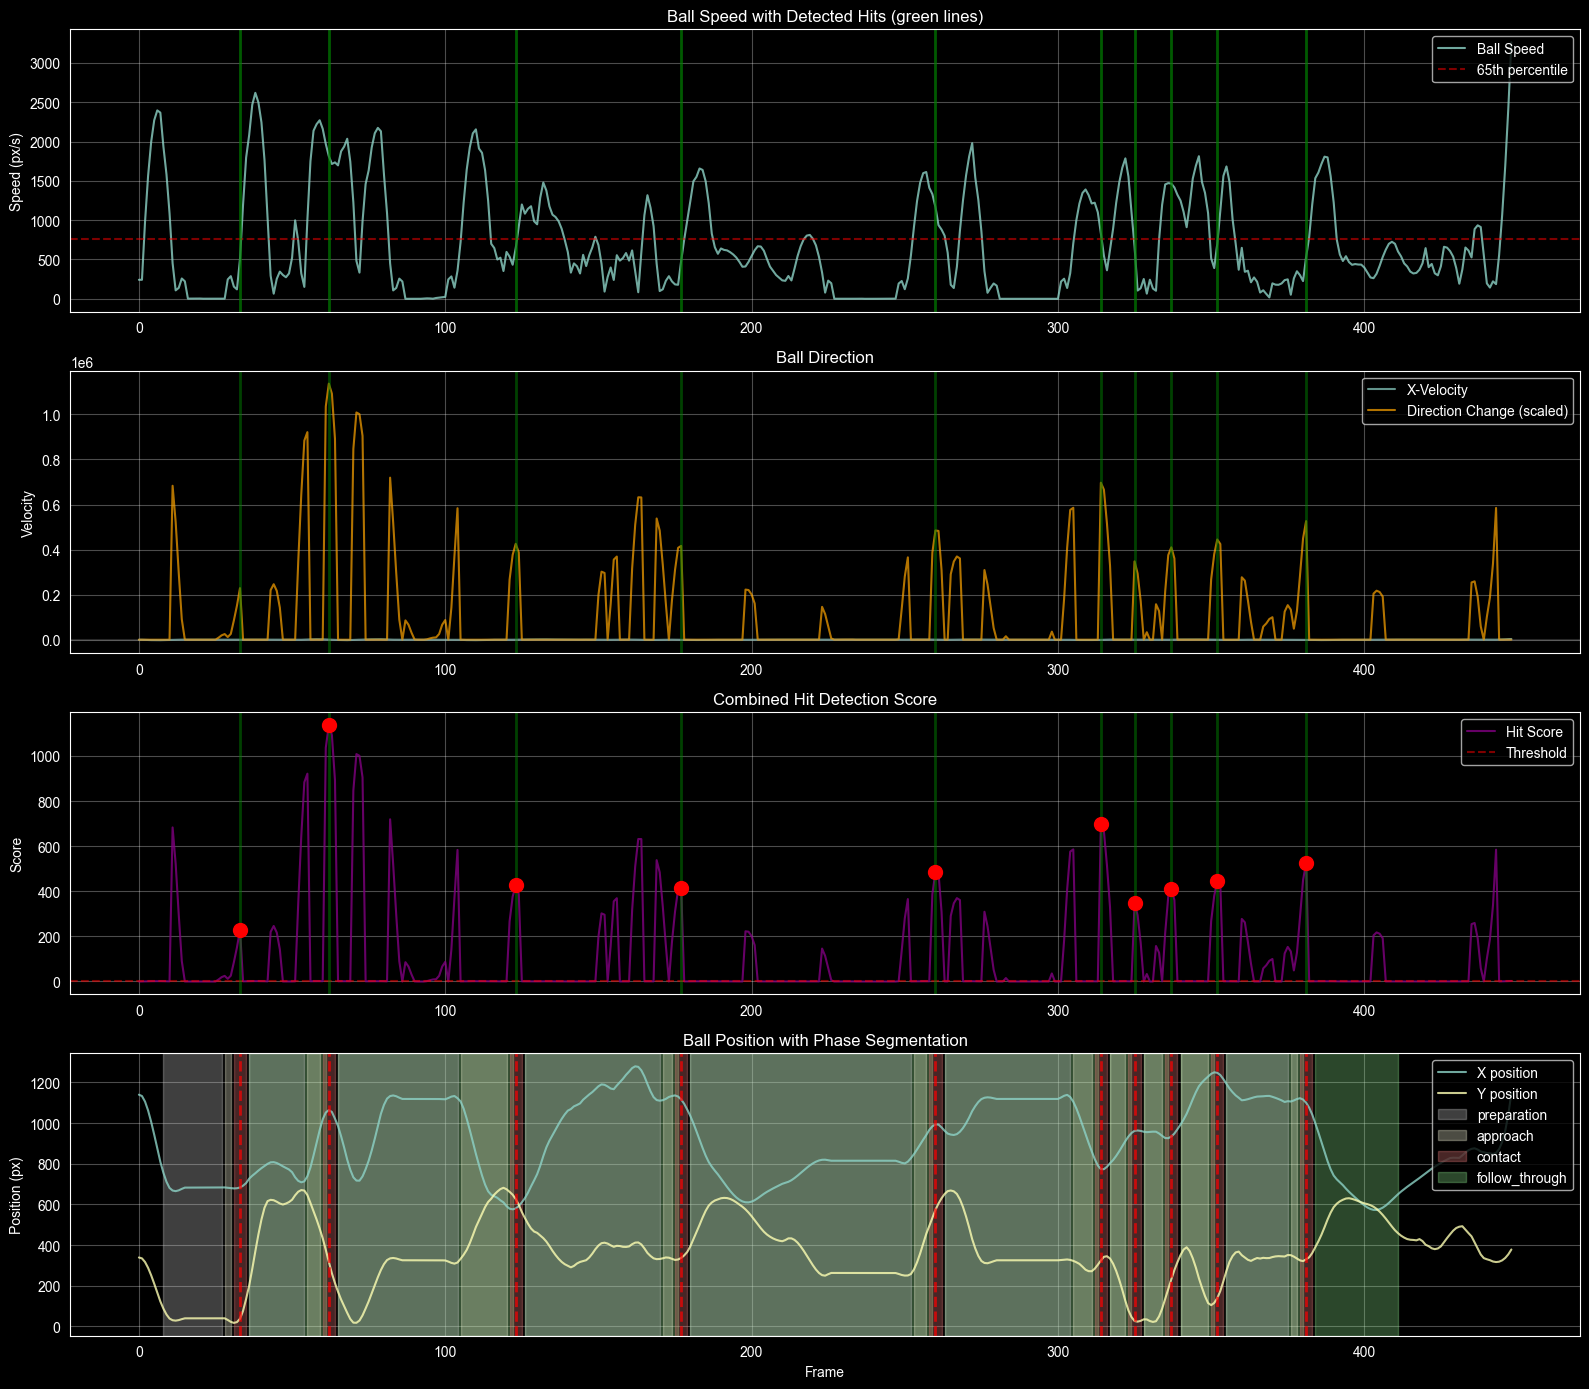

Saved output_clips_v2/analysis.png


In [14]:
# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(16, 14))

# Plot 1: Speed
ax1 = axes[0]
ax1.plot(speed, label='Ball Speed', alpha=0.8, linewidth=1.5)
ax1.axhline(np.percentile(speed, 65), color='r', linestyle='--', alpha=0.5, label='65th percentile')
for hit in hits:
    ax1.axvline(hit, color='green', alpha=0.7, linewidth=2)
ax1.set_ylabel('Speed (px/s)')
ax1.set_title('Ball Speed with Detected Hits (green lines)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Direction
ax2 = axes[1]
ax2.plot(dir_x, label='X-Velocity', alpha=0.7)
ax2.plot(dir_change * 500, label='Direction Change (scaled)', alpha=0.7, color='orange')
for hit in hits:
    ax2.axvline(hit, color='green', alpha=0.5, linewidth=2)
ax2.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax2.set_ylabel('Velocity')
ax2.set_title('Ball Direction')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Plot 3: Hit score
ax3 = axes[2]
ax3.plot(hit_score, label='Hit Score', alpha=0.8, color='purple')
ax3.axhline(HIT_SCORE_THRESHOLD, color='r', linestyle='--', alpha=0.5, label='Threshold')
for hit in hits:
    ax3.axvline(hit, color='green', alpha=0.5, linewidth=2)
    ax3.scatter([hit], [hit_score[hit]], color='red', s=100, zorder=5)
ax3.set_ylabel('Score')
ax3.set_title('Combined Hit Detection Score')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Plot 4: Position with phases
ax4 = axes[3]
ax4.plot(smooth_pos[:, 0], label='X position', alpha=0.8)
ax4.plot(smooth_pos[:, 1], label='Y position', alpha=0.8)

phase_colors = {
    'preparation': 'lightgray',
    'approach': 'lightyellow',
    'contact': 'lightcoral',
    'follow_through': 'lightgreen'
}

for v in volleys:
    phases = segment_phases(v, speed, fps)
    for phase_name, (s, e) in phases.items():
        if e > s:
            label = phase_name if v['index'] == 1 else ''
            ax4.axvspan(s, e, alpha=0.3, color=phase_colors[phase_name], label=label)

for hit in hits:
    ax4.axvline(hit, color='red', alpha=0.7, linewidth=2, linestyle='--')

ax4.set_xlabel('Frame')
ax4.set_ylabel('Position (px)')
ax4.set_title('Ball Position with Phase Segmentation')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/analysis.png", dpi=150)
plt.show()
print(f"Saved {OUTPUT_DIR}/analysis.png")

In [15]:
# ============================================================
# PRINT DETAILED RESULTS
# ============================================================

print("\n" + "="*70)
print("VOLLEY SEGMENTATION RESULTS")
print("="*70)

for v in volleys:
    phases = segment_phases(v, speed, fps)
    
    print(f"\nVolley {v['index']}:")
    print(f"  Frames: {v['start']}-{v['end']} ({(v['end']-v['start'])/fps:.2f}s)")
    print(f"  Hit: frame {v['hit_frame']} ({v['hit_frame']/fps:.2f}s)")
    print(f"  Ball speed at hit: {speed[v['hit_frame']]:.0f} px/s")
    print(f"  Phases:")
    for phase_name, (s, e) in phases.items():
        duration_ms = (e - s) / fps * 1000
        print(f"    {phase_name:15}: frames {s:3}-{e:3} ({duration_ms:5.0f}ms)")


VOLLEY SEGMENTATION RESULTS

Volley 1:
  Frames: 8-61 (1.77s)
  Hit: frame 33 (1.10s)
  Ball speed at hit: 506 px/s
  Phases:
    preparation    : frames   8- 27 (  634ms)
    approach       : frames  28- 30 (   67ms)
    contact        : frames  31- 35 (  133ms)
    follow_through : frames  36- 61 (  834ms)

Volley 2:
  Frames: 36-122 (2.87s)
  Hit: frame 62 (2.07s)
  Ball speed at hit: 1814 px/s
  Phases:
    preparation    : frames  36- 54 (  601ms)
    approach       : frames  55- 59 (  133ms)
    contact        : frames  60- 64 (  133ms)
    follow_through : frames  65-122 ( 1902ms)

Volley 3:
  Frames: 65-176 (3.70s)
  Hit: frame 123 (4.10s)
  Ball speed at hit: 642 px/s
  Phases:
    preparation    : frames  65-104 ( 1301ms)
    approach       : frames 105-120 (  501ms)
    contact        : frames 121-125 (  133ms)
    follow_through : frames 126-176 ( 1668ms)

Volley 4:
  Frames: 126-259 (4.44s)
  Hit: frame 177 (5.91s)
  Ball speed at hit: 481 px/s
  Phases:
    preparation  

In [ ]:
# ============================================================
# CREATE DEBUG VIDEO
# ============================================================

print("Creating debug video...")

phase_colors_bgr = {
    'preparation': (180, 180, 180),
    'approach': (0, 255, 255),
    'contact': (0, 0, 255),
    'follow_through': (0, 255, 0)
}

# Map frames to phases
frame_phases = {}
for v in volleys:
    phases = segment_phases(v, speed, fps)
    for phase_name, (s, e) in phases.items():
        for f in range(s, min(e + 1, len(frames))):
            frame_phases[f] = (v['index'], phase_name)

out = cv2.VideoWriter(
    f"{OUTPUT_DIR}/debug_tracking.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    size
)

for i, frame in enumerate(frames):
    vis = frame.copy()
    
    # Draw trail
    for j in range(max(0, i - 12), i):
        if final_pos[j]:
            alpha = (j - (i - 12)) / 12
            x, y = int(final_pos[j][0]), int(final_pos[j][1])
            cv2.circle(vis, (x, y), 3, (0, int(200*alpha), int(255*(1-alpha))), -1)
    
    # Draw ball position
    x, y = int(smooth_pos[i, 0]), int(smooth_pos[i, 1])
    cv2.circle(vis, (x, y), 10, (0, 255, 0), 2)
    
    if final_pos[i]:
        rx, ry = int(final_pos[i][0]), int(final_pos[i][1])
        cv2.circle(vis, (rx, ry), 6, (255, 0, 0), -1)
    
    # Mark hits
    if i in hits:
        cv2.putText(vis, "HIT!", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4)
        cv2.circle(vis, (x, y), 25, (0, 0, 255), 3)
    
    # Show phase
    if i in frame_phases:
        v_idx, phase = frame_phases[i]
        color = phase_colors_bgr.get(phase, (255, 255, 255))
        cv2.putText(vis, f"Volley {v_idx}: {phase}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        cv2.rectangle(vis, (30, 70), (300, 90), color, -1)
    
    # Speed and frame info
    cv2.putText(vis, f"Speed: {int(speed[i])} px/s", (30, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(vis, f"Frame: {i} ({i/fps:.2f}s)", (30, size[1] - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    out.write(vis)

out.release()
print(f"Saved {OUTPUT_DIR}/debug_tracking.mp4")

In [ ]:
# ============================================================
# SAVE VOLLEY AND PHASE CLIPS
# ============================================================

print("Saving volley clips...")

for v in volleys:
    v_dir = f"{OUTPUT_DIR}/volley_{v['index']}"
    os.makedirs(v_dir, exist_ok=True)
    
    # Full volley
    v_frames = frames[v['start']:v['end']+1]
    save_clip(v_frames, fps, f"{v_dir}/full_volley.mp4", size)
    
    # Phase clips
    phases = segment_phases(v, speed, fps)
    for phase_name, (s, e) in phases.items():
        if e > s and s < len(frames) and e < len(frames):
            p_frames = frames[s:e+1]
            if len(p_frames) > 0:
                save_clip(p_frames, fps, f"{v_dir}/{phase_name}.mp4", size)
    
    print(f"  Volley {v['index']}: frames {v['start']}-{v['end']}, hit at {v['hit_frame']}")

print("\nDone!")

In [ ]:
# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("PICKLEBALL CLIP SPLICING MVP v2 - SUMMARY")
print("="*60)

print(f"\nInput: {VIDEO_PATH}")
print(f"Duration: {len(frames)/fps:.2f}s ({len(frames)} frames at {fps:.2f} FPS)")

detected = sum(1 for p in final_pos if p is not None)
print(f"\nDetection rate: {detected}/{len(frames)} ({100*detected/len(frames):.1f}%)")
print(f"Detected {len(hits)} hits")
print(f"Segmented into {len(volleys)} volleys")

print(f"\nOutput files:")
print(f"  {OUTPUT_DIR}/analysis.png")
print(f"  {OUTPUT_DIR}/debug_tracking.mp4")
for v in volleys:
    print(f"  {OUTPUT_DIR}/volley_{v['index']}/")

In [ ]:
# ============================================================
# INTERACTIVE PREVIEW (Optional)
# ============================================================
# Uncomment to run interactive preview with keyboard controls

# def interactive_preview():
#     i = 0
#     paused = False
#     
#     while True:
#         frame = frames[i].copy()
#         x, y = int(smooth_pos[i, 0]), int(smooth_pos[i, 1])
#         cv2.circle(frame, (x, y), 10, (0, 255, 0), 2)
#         
#         if i in hits:
#             cv2.putText(frame, "HIT!", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4)
#         
#         if i in frame_phases:
#             v_idx, phase = frame_phases[i]
#             cv2.putText(frame, f"V{v_idx}: {phase}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
#         
#         cv2.putText(frame, f"Frame {i} | Space=pause, Q=quit", (30, frame.shape[0] - 30),
#                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
#         
#         cv2.imshow("Preview", frame)
#         
#         delay = 1 if paused else int(1000 / fps)
#         key = cv2.waitKey(delay) & 0xFF
#         
#         if key == ord('q'):
#             break
#         elif key == ord(' '):
#             paused = not paused
#         elif key == ord(','):
#             i = max(0, i - 1)
#         elif key == ord('.'):
#             i = min(len(frames) - 1, i + 1)
#         elif not paused:
#             i = (i + 1) % len(frames)
#     
#     cv2.destroyAllWindows()
# 
# interactive_preview()